## Submit Portfolio of Trades to QRT

In [ ]:
import os
import logging
import numpy as np
import pandas as pd
from glob import glob
from typing import Literal
import matplotlib.pyplot as plt
from local_data.LSEG_data import *
from clients import finance_client as fin
from clients.qsec_client.sample_code import *

logger = logging.getLogger(__name__)

GROUP_ID = 'ICL05'
USER = 'q8576'
KEY_PATH = os.path.expanduser('~/.ssh/icl05_id_rsa')
# _SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__))
_SCRIPT_DIR = ''
DATA_DIR = os.path.join(_SCRIPT_DIR, 'local_data', 'data')
PRICE_DIR = os.path.join(DATA_DIR, 'lseg')
TARGETS_DIR = os.path.join(_SCRIPT_DIR, 'target_files')

logging.basicConfig(filename=os.path.join(_SCRIPT_DIR, 'logs/send_portfolio.log'), level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')


def send_new_portfolio(targets: pd.DataFrame, region: Literal['AMER', 'EMEA']):
    """Update the actual team portfolio at the current market prices.
    targets = pd.DataFrame({'internal_code': 'AAPL.OQ', 'currency': 'USD', 'target_notional': 100})
    """
    try:
        target_path = prepare_targets_file(targets, GROUP_ID, region, os.path.join(TARGETS_DIR, region))
        logger.info(pd.read_csv(target_path))
        formating_issues = validate_targets_file(target_path)
        if formating_issues == []:
            upload_targets_file(
                targets_csv_path=target_path, 
                region=region, 
                sftp_username=USER, 
                private_key_path=KEY_PATH,
                sftp_host='sftp.qrt.cloud'
            )
            logging.info(f"Portfolio successfully uploaded: {target_path}")
        else:
            logging.error(f"Validation failed, portfolio not uploaded: {target_path}. Issues: {formating_issues}")
            raise
    except Exception as e:
        logging.error(f"Failed to send portfolio: {e}")
        raise

def beta(ric: str, market: Literal['.SPX', '.STOXX50E']) -> float | None:
    """The QRT calculation for the market beta of a stock"""
    if ric in ['.SPX', '.STOXX50E']:
        return 1.0

    stock_return = pd.read_parquet(os.path.join(PRICE_DIR, f"RIC={ric}")).set_index("Date")['Close'].dropna().pct_change().tail(250).dropna()
    benchmark_return = pd.read_parquet(os.path.join(PRICE_DIR, f"RIC={market}")).set_index("Date")['Close'].dropna().pct_change().tail(250).dropna()

    if stock_return.index[-1] < benchmark_return.index[-3]:
        # print(f"Skipping {isin}: last trade {stock_return.index[-1]} is before {benchmark_return.index[-2]}")
        return None

    # beta = cov(stock, mkt) / var(mkt)
    cov = (stock_return).cov(benchmark_return)
    var = (benchmark_return).var()
    beta_value = cov / var

    # QRT beta calculation
    return 0.2 + 0.8 * float(beta_value)

def portfolio_beta(positions: pd.Series, market: Literal['.SPX', '.STOXX50E']) -> float:
    weights = positions / positions.abs().sum()
    total = 0.0
    for ric in positions.index:
        b = beta(ric, market)
        if b is None:
            print(f"Skipping {ric}: no beta")
            continue
        total += weights[ric] * b
    return total

def forced_hedge(positions: pd.Series, market: Literal['.SPX', '.STOXX50E']) -> float:
    """Nominal currency to hedge against beta exposure"""
    hedge = -portfolio_beta(positions, market) * positions.abs().sum()
    if abs(hedge) < 0.01:
        return 0.0
    return hedge.round(2)

def risk(positions: pd.Series, date: str = None) -> int:
    """Annualised volatility of daily PnL in currency units using previous 60 trading days of returns
    QRT calculation for the portfolio risk
    Parameters:
        positions: RIC-to-value (currency) Series e.g. pd.Series({'AAPL': -2500, 'V': 4000}).
        date: Close date to measure risk exposure for.
    Returns:
        int: Nominal risk exposure."""
    if date is None:
        date = pd.Timestamp.now().strftime("%Y-%m-%d")

    date = pd.Timestamp(date)

    returns = []
    # Last 60 tradin days of position returns
    for ric in positions.index:
        df = pd.read_parquet(
            os.path.join(PRICE_DIR, f"RIC={ric}")
        ).set_index("Date")[['Close']]

        df.index = pd.to_datetime(df.index)
        df = df[~df.index.duplicated(keep='first')]
        df = df[df.index <= date]
        df = df.dropna()

        # strictly last 60 calendar days from date
        cutoff = date - pd.Timedelta(days=60)
        prices = df[df.index >= cutoff]
        rets = prices.pct_change().dropna()

        returns.append(rets.rename(columns={'Close': ric}))

    returns_matrix = pd.concat(returns, axis=1).dropna()
    returns_matrix = returns_matrix[positions.index]

    daily_pnl = returns_matrix @ positions

    risk = daily_pnl.std(ddof=1) * np.sqrt(252)

    return int(risk.round())

def load_returns_from(rics: pd.Index | list, start: str = '2026-01-01') -> pd.DataFrame:
    """Get daily returns DataFrame from local data, one column per RIC
    Parameters:
        rics: List of RIC's to fetch price data for.
        start: String date to get returns from.
    Returns:
        pd.DataFrame: Returns with date as index and RIC in columns.
    """
    returns_list = []
    for ric in rics:
        df = pd.read_parquet(os.path.join(PRICE_DIR, f"RIC={ric}")).set_index("Date")[['Close']].dropna()
        df = df[~df.index.duplicated(keep='first')]
        df.index = pd.to_datetime(df.index)
        df = df[df.index >= start]
        ret = df['Close'].pct_change().fillna(0)
        returns_list.append(ret.rename(ric))

    returns_df = pd.concat(returns_list, axis=1)

    cols_with_nulls = returns_df.columns[returns_df.isnull().any()]

    for col in cols_with_nulls:
        if returns_df[col].isnull().sum() == 1 and pd.isna(returns_df[col].iloc[-1]):
            returns_df[col] = returns_df[col].ffill()
            print(f"Forward-filled last date for {col}")
        else:
            print(f"Skipped {col}: multiple missing dates")
            returns_df = returns_df.drop(columns=col)

    return returns_df

def plot_portfolio_returns(positions: pd.Series, market: Literal['.SPX', '.STOXX50E'], start_date: str = '2026-01-01', benchmark: pd.Series = None, figsize=(10, 5)):
    """Plot cumulative portfolio returns (%) since start_date.

    Parameters:
        positions: Portfolio nominal amounts, e.g. pd.Series({'AAPL.OQ': 500_000, 'V.N': -400_000})
        start_date: Date to start calculating returns from assuming bought at close,
                    first plotted point has zero cumulative return.
        benchmark: ISIN to notional series for the benchmark portfolio.
    """
    if benchmark is None:
        benchmark = pd.Series({market: 1})

    def cum_returns(returns_df: pd.DataFrame, pos: pd.Series) -> pd.Series:
        returns_df = returns_df[pos.index]
        total_notional = pos.abs().sum()
        weights = pos / total_notional
        daily_ret = (returns_df * weights).sum(axis=1)
        return (1 + daily_ret).cumprod() - 1

    # Portfolio
    port_returns_df = load_returns_from(positions.index, start_date)
    port_cum = cum_returns(port_returns_df, positions[port_returns_df.columns])

    # Benchmark
    bench_returns_df = load_returns_from(benchmark.index, start_date)
    bench_cum = cum_returns(bench_returns_df, benchmark)

    # Plot
    if True:
        plt.figure(figsize=figsize)
        plt.plot(port_cum.index, port_cum.values * 100, label='Portfolio')
        plt.plot(bench_cum.index, bench_cum.values * 100, label=f'Benchmark ({", ".join(benchmark.index)})', linestyle='--')
        plt.title(f'Portfolio vs Benchmark Cumulative Return since {start_date}')
        plt.xlabel('Date')
        plt.ylabel('Cumulative Return (%)')
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

def most_recent_positions(region: Literal['AMER', 'EMEA'], pattern: str = "*.csv") -> pd.Series:
    """
    Reads the most recent file positions in `folder_path` matching the `pattern` and returns as a DataFrame.
    
    Parameters:
        folder_path (str): Path to the folder containing files.
        pattern (str): Glob pattern to match files, default '*.csv'.
    
    Returns:
        pd.Series: Series of the most recent file positions.
    """
    # Build full search pattern
    search_pattern = os.path.join(TARGETS_DIR, region, pattern)
    
    # Get all matching files
    files = glob(search_pattern)
    if not files:
        raise FileNotFoundError(f"No files found in {TARGETS_DIR}/{region} matching {pattern}")
    
    # Get the most recently modified file
    most_recent_file = max(files, key=os.path.getmtime)
    
    # Read into DataFrame
    df = pd.read_csv(most_recent_file)

    df = pd.Series(data=df["target_notional"].values, index=df["ric"])

    return df

def eur_usd(date: str = None) -> float:
    return float(fin.yf_price("EURUSD=X", period="1d", end=date)['EURUSD=X'].iloc[-1])


In [127]:
# get_history(['DISCA.OQ', 'WBD.OQ'], start='2026-01-01').tail(30)
# pd.read_parquet(f"local_data/data/lseg/RIC={'WBD.OQ'}").set_index('Date').dropna().tail(30)

### Prepare Universe Price Data

In [ ]:
# from local_data.LSEG_data import *
# from QRT_utils import *

stock_prices = pd.read_parquet("local_data/data/lseg")

prices_df_rua = get_timeseries(stock_prices, value_col='Close', index='.SPX'); vol_df_rua = get_timeseries(stock_prices, value_col='Volume', index='.SPX')
vol_eligible_rua = eligible_to_trade(prices_df_rua, vol_df_rua, index='.SPX')

prices_df_stoxx = get_timeseries(stock_prices, value_col='Close', index='.STOXX50E'); vol_df_stoxx = get_timeseries(stock_prices, value_col='Volume', index='.STOXX50E')
vol_eligible_stoxx = eligible_to_trade(prices_df_stoxx, vol_df_stoxx, index='.STOXX50E')

### Momentum Long-Short Portfolio

In [ ]:
import cvxpy as cp

EXECUTION_COST_BPS = 2e-4
FINANCING_COST_ANNUAL = 0.005

def momentum_portfolio(
    price_data: pd.DataFrame,
    vol_eligible: pd.DataFrame,
    mkt_index: str,
    lookback: int = 252,
    portfolio_start: str = '2026-01-01',
    vol_quantile: float = 0.90,
    mom_quantile_top: float = 0.85,
    mom_quantile_bottom: float = 0.15,
    target_vol: float = 0.10,
    weight_max: float = 0.10,
    weight_min: float = 0.005,
    target_risk: float = 300_000.0
):
    """
    Optimize a beta-neutral momentum portfolio with volatility filtering.

    Args:
        price_data:          Full price DataFrame with tickers as columns, including '.SPX'.
        vol_eligible:        Truth DataFrame for dates when the $ADV ≥ 5M.
        lookback:            Number of trading days of history used to estimate momentum,
                             vol, covariance, and betas. Training window ends the day
                             before portfolio_start.
        portfolio_start:     First date of the live portfolio. The closing price on this
                             date is the entry price. Training uses [portfolio_start -
                             lookback days, portfolio_start).
        vol_quantile:        Max volatility percentile filter.
        mom_quantile_top:    Top momentum percentile to go long.
        mom_quantile_bottom: Bottom momentum percentile to go short.
        target_vol:          Max annualized portfolio volatility.
        weight_max:          Max absolute weight per stock.
        weight_min:          Min absolute weight per stock.
        target_risk:         Dollar notional scalar for position sizing.

    Returns:
        positions: pd.Series of dollar positions (rounded), indexed by ticker.
        stats:     dict with expected return, vol, sharpe, beta, gross leverage,
                   universe size, and entry_date.
    """

    # --- Locate entry date in index ---
    all_dates = price_data.index
    start_idx = all_dates.searchsorted(pd.Timestamp(portfolio_start))
    
    if start_idx >= len(all_dates):
        entry_date = pd.Timestamp(portfolio_start)
    else:
        entry_date = all_dates[start_idx] # actual trading day on or after portfolio_start
    
    # --- Training window: lookback days ending strictly before entry ---
    if start_idx < lookback:
        raise ValueError(
            f"Not enough history before {entry_date}: need {lookback} days, "
            f"have {start_idx}."
        )

    train_prices = price_data.iloc[start_idx - lookback : start_idx]
    returns      = train_prices.ffill(limit=2).pct_change(fill_method=None).iloc[1:].dropna(axis=1, how='any')

    # --- Volatility filter ---
    ann_vol    = returns.std() * np.sqrt(252)
    vol_filter = ann_vol[ann_vol < ann_vol.quantile(vol_quantile)].index

    # --- Momentum filter (point-in-time: first to last of training window) ---
    momentum   = (train_prices.iloc[-1] / train_prices.ffill().iloc[0]) - 1
    top        = momentum[momentum >= momentum.quantile(mom_quantile_top)].index
    bottom     = momentum[momentum <= momentum.quantile(mom_quantile_bottom)].index
    mom_filter = top.union(bottom)

    # --- Universe --- Vol checks out, Mom checks out, $ADV checks out, active lseg ric's
    lseg_rics = get_historical_index_constituents()
    active_lseg_isin = lseg_rics[(lseg_rics['Year']==2026) & (lseg_rics['Index']==mkt_index)]['RIC'].unique()
    vol_eligible_tickers = vol_eligible.columns[vol_eligible.loc[entry_date]]

    # print('mom_filter', len(mom_filter.to_list()))
    # print('vol_eligible_tickers', len(vol_eligible_tickers.to_list()))
    universe = vol_filter.intersection(mom_filter).intersection(vol_eligible_tickers).intersection(active_lseg_isin).drop(mkt_index, errors='ignore')
    
    if len(universe) == 0:
        raise ValueError("No stocks passed the filters. Adjust parameters.")

    ret_u      = returns[universe]
    ret_filled = ret_u.dropna(thresh=int(0.95 * len(ret_u)), axis=1)
    mkt_idx    = returns[mkt_index].ffill(limit=2)
    valid_idx  = mkt_idx.dropna().index.intersection(ret_filled.index)

    ret_filled = ret_filled.loc[valid_idx]
    mkt_idx = mkt_idx.loc[valid_idx]

    # --- Stats ---
    mu  = ret_filled.mean() * 252
    cov = ret_filled.cov() * 252
    cov += np.eye(len(cov)) * 1e-6
    b   = ret_filled.apply(lambda c: np.cov(c, mkt_idx)[0, 1] / np.var(mkt_idx))

    bad      = b[b.isna()].index
    universe = universe.drop(bad)
    ret_filled = ret_filled[universe]
    mu, cov, b = mu[universe], cov.loc[universe, universe], b[universe]

    # --- Optimisation ---
    w    = cp.Variable(len(universe))
    prob = cp.Problem(
        cp.Maximize(mu.values @ w),
        [
            cp.quad_form(w, cov.values) <= target_vol ** 2,
            b.values @ w == 0,
            cp.sum(w) == 0,
            cp.norm(w, 1) <= 2,
            w >= -weight_max,
            w <= weight_max,
        ]
    )

    # prob.solve(solver=cp.ECOS, verbose=False)
    prob.solve(solver=cp.SCS, verbose=False)

    if prob.status not in (cp.OPTIMAL, cp.OPTIMAL_INACCURATE):
        raise RuntimeError(f"Solver failed: {prob.status}")

    weights   = pd.Series(w.value, index=universe)
    weights   = weights[abs(weights) >= weight_min]
    mu, cov, b = mu[weights.index], cov.loc[weights.index, weights.index], b[weights.index]

    # 252-day in-sample vol for reporting (matches optimizer)
    insample_vol = float(np.sqrt(weights @ cov @ weights))

    # 60-day vol for position sizing (matches risk())
    cutoff = entry_date - pd.Timedelta(days=60)
    train_returns = ret_filled[weights.index].loc[ret_filled.index >= cutoff]


    daily_pnl_unit = train_returns @ weights
    unit_risk = daily_pnl_unit.std(ddof=1) * np.sqrt(252)
    scale = target_risk / unit_risk
    positions = weights * scale

    dollar_risk = (train_returns @ positions).std(ddof=1) * np.sqrt(252)

    gross_notional = int(positions.abs().sum())  # in dollars

    exec_cost_dollar    = gross_notional * EXECUTION_COST_BPS  # 2 bps on gross
    financing_cost_dollar = gross_notional * FINANCING_COST_ANNUAL / 360 # 0.5% on GMV

    stats = {
        'entry_date':             str(entry_date.date()),
        # 'In-Sample Return':       f'{mu @ weights:.2%}',
        # 'In-Sample Vol':          f'{insample_vol:.2%}',
        # 'Risk':                   f'${dollar_risk:,.0f}',
        # 'Sharpe':                 f'{(mu @ weights) / unit_risk:.2f}',
        'Beta':                   f'{(b * weights).sum():.3f}',
        'Gross Leverage':         f'{weights.abs().sum():.2f}x',
        'Gross Notional':         f'${gross_notional:,.0f}',
        'Exec Cost ($)':          f'${exec_cost_dollar:,.0f}',
        'Financing Cost ($/day)': f'${financing_cost_dollar:,.0f}',
        'Universe Size':          len(positions),
    }

    return positions, stats

start_date = '2026-03-31'
positions_rua, stats_rua = momentum_portfolio(
    prices_df_rua, vol_eligible_rua, mkt_index='.SPX', lookback=252, portfolio_start=start_date, target_risk=500_000
)
print(pd.Series(stats_rua))

positions_stoxx, stats_stoxx = momentum_portfolio(
    prices_df_stoxx, vol_eligible_stoxx, mkt_index='.STOXX50E', lookback=252, portfolio_start=start_date, target_risk=500_000
)
print(pd.Series(stats_stoxx))

entry_date                2026-03-31
Beta                          -0.004
Gross Leverage                 1.96x
Gross Notional            $8,453,187
Exec Cost ($)                 $1,691
Financing Cost ($/day)          $117
Universe Size                     79
dtype: object
entry_date                2026-03-31
Beta                           0.006
Gross Leverage                 1.98x
Gross Notional            $7,427,550
Exec Cost ($)                 $1,486
Financing Cost ($/day)          $103
Universe Size                     52
dtype: object


[2002-03-20] Skipping: Not enough history before 2002-03-20 00:00:00: need 252 days, have 55.
[2002-04-02] Skipping: Not enough history before 2002-04-02 00:00:00: need 252 days, have 62.
[2002-04-11] Skipping: Not enough history before 2002-04-11 00:00:00: need 252 days, have 69.
[2002-04-22] Skipping: Not enough history before 2002-04-22 00:00:00: need 252 days, have 76.
[2002-05-02] Skipping: Not enough history before 2002-05-02 00:00:00: need 252 days, have 83.
[2002-05-13] Skipping: Not enough history before 2002-05-13 00:00:00: need 252 days, have 90.
[2002-05-22] Skipping: Not enough history before 2002-05-22 00:00:00: need 252 days, have 97.
[2002-05-31] Skipping: Not enough history before 2002-05-31 00:00:00: need 252 days, have 104.
[2002-06-11] Skipping: Not enough history before 2002-06-11 00:00:00: need 252 days, have 111.
[2002-06-20] Skipping: Not enough history before 2002-06-20 00:00:00: need 252 days, have 118.
[2002-07-01] Skipping: Not enough history before 2002-07-

<Axes: title={'center': 'Cumulative Return (%)'}, xlabel='Date'>

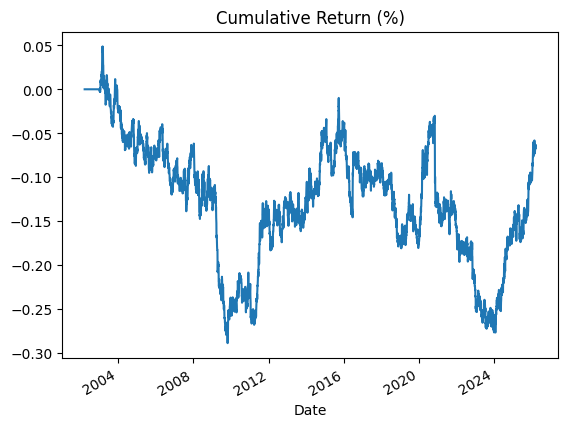

In [ ]:
def screen_event_impact(
    positions: pd.Series,
    price_data: pd.DataFrame,
    reb_date: pd.Timestamp,
    market: Literal['.SPX', '.STOXX50E'],
    days: int = 20,
    z_threshold: float = 1.0,
    plot: bool = True,
) -> tuple[pd.DataFrame, pd.Series]:
    """
    Screen positions for short-term price moves that work against you
    using a z-score approach: flag positions whose adverse return is
    more than z_threshold standard deviations worse than their same-side
    peers.  Removed notional is redistributed equally across survivors,
    then the portfolio is rescaled to match the original risk level,
    and a market hedge is added to target beta ≈ 0.

    Parameters
    ----------
    positions   : pd.Series  – RIC → signed notional (positive = long)
    market      : str         – benchmark RIC for beta calc
    days        : int         – look-back window
    z_threshold : float       – how many σ worse than same-side mean to flag
    plot        : bool        – show normalised-price chart

    Returns
    -------
    flagged    : DataFrame of flagged positions sorted worst-first
    reweighted : pd.Series with reversals removed, capital redistributed,
                 risk matched, and beta ≈ 0
    """
    ret_col = f"{days}d_return_pct"
    ric_data: dict[str, dict] = {}
    norm_series: dict[str, tuple[pd.Series, str]] = {}

    # ---- pass 1: collect returns for every position ----
    for ric, notional in positions.items():

        close = price_data[ric].loc[:reb_date].iloc[:-1].dropna().tail(days)
        if close.empty or len(close) < days:
            continue

        ret = close.iloc[-1] / close.iloc[0] - 1
        side = "long" if notional > 0 else "short"
        pain = -ret if side == "long" else ret

        norm_series[ric] = (close / close.iloc[0] * 100, side)
        ric_data[ric] = {
            "notional": notional,
            "side": side,
            "ret": ret,
            "pain": pain,
        }

    # ---- pass 2: z-score within each side ----
    rows = []
    for side_label in ("long", "short"):
        peers = {r: d for r, d in ric_data.items() if d["side"] == side_label}
        if len(peers) < 2:
            continue
        pains = np.array([d["pain"] for d in peers.values()])
        mu, sigma = pains.mean(), pains.std(ddof=1)
        if sigma < 1e-9:
            continue

        for ric, d in peers.items():
            z = (d["pain"] - mu) / sigma
            if z > z_threshold:
                rows.append({
                    "RIC": ric,
                    "notional": d["notional"],
                    "side": side_label,
                    ret_col: round(d["ret"] * 100, 2),
                    "z_score": round(z, 2),
                    "action": "reduce / exit",
                })

    flagged = (
        pd.DataFrame(rows)
        .sort_values("z_score", ascending=False)
        .reset_index(drop=True)
    )

    # ---- build reweighted positions ----
    original_risk = risk(positions)

    flagged_rics = set(flagged["RIC"].values) if not flagged.empty else set()
    flagged_idx = list(set(flagged_rics).intersection(positions.index))
    remaining = positions.drop(index=flagged_idx)

    if remaining.empty:
        return flagged, positions
    else:
        longs = remaining[remaining > 0]
        shorts = remaining[remaining < 0]

        flagged_pos = positions.loc[flagged_idx]
        freed_long = flagged_pos[flagged_pos > 0].sum()
        freed_short = flagged_pos[flagged_pos < 0].sum()

        if not longs.empty:
            remaining.loc[longs.index] += freed_long / len(longs)
        if not shorts.empty:
            remaining.loc[shorts.index] += freed_short / len(shorts)

    reweighted = remaining.copy()

    new_risk = risk(reweighted)
    if new_risk > 0:
        reweighted *= original_risk / new_risk

    # hedge to beta ≈ 0
    hedge = forced_hedge(reweighted, market)
    if abs(hedge) > 0.01:
        reweighted[market] = reweighted.get(market, 0.0) + hedge

    # ---- plot ----
    if plot and norm_series:
        fig, (ax_l, ax_s) = plt.subplots(1, 2, figsize=(14, 5))
        for ric, (series, side) in norm_series.items():
            ax = ax_l if side == "long" else ax_s
            style = ({"linewidth": 2, "alpha": 0.9}
                     if ric in flagged_rics else {"alpha": 0.35})
            ax.plot(series, label=ric, **style)

        for ax, title in [(ax_l, "Longs"), (ax_s, "Shorts")]:
            ax.set_title(title)
            ax.axhline(100, color="black", ls="--", lw=0.5)
            ax.set_ylabel("Normalised Price")
            ax.tick_params(axis="x", rotation=45)
            if ax.has_data():
                ax.legend(fontsize=7, loc="best")

        fig.suptitle(
            f"Last {days}d — z>{z_threshold} flagged positions highlighted",
            fontsize=11,
        )
        plt.tight_layout()
        plt.show()

    return flagged, reweighted

def backtest_momentum(
    price_data: pd.DataFrame,
    vol_eligible: pd.DataFrame,
    mkt_index: Literal['.SPX', '.STOXX50E'],
    start_date: str = '2026-01-01',
    end_date: str = None,
    rebalance_freq: int = 10,
    lookback: int = 252,
    target_risk: float = 500_000,
    initial_capital: float = 10_000_000,
    exec_bps: float = 2.0,
    financing_annual: float = 0.005,
    **kwargs
):
    all_dates = price_data.index
    start_idx = all_dates.searchsorted(pd.Timestamp(start_date))
    end_idx = len(all_dates) if end_date is None else all_dates.searchsorted(pd.Timestamp(end_date))

    rebal_indices = list(range(start_idx, end_idx, rebalance_freq))

    daily_ret = pd.Series(0.0, index=all_dates[start_idx:end_idx], dtype=float)
    turnovers = []
    prev_positions = pd.Series(dtype=float)
    nav = initial_capital

    for i, reb_idx in enumerate(rebal_indices):
        reb_date = all_dates[reb_idx]

        if i + 1 < len(rebal_indices):
            next_idx = rebal_indices[i + 1]
        else:
            next_idx = end_idx

        try:
            positions, stats = momentum_portfolio(
                price_data, vol_eligible,
                mkt_index=mkt_index,
                lookback=lookback,
                portfolio_start=str(reb_date.date()),
                target_risk=target_risk,
                **kwargs
            )

            flagged, positions = screen_event_impact(
                positions,
                price_data=price_data,
                reb_date=reb_date,
                market=mkt_index,
                days=20,
                z_threshold=1.0,
                plot=False
            )
        except (ValueError, RuntimeError) as e:
            print(f"[{reb_date.date()}] Skipping: {e}")
            continue

        # turnover
        all_tickers = positions.index.union(prev_positions.index)
        old = prev_positions.reindex(all_tickers, fill_value=0)
        new = positions.reindex(all_tickers, fill_value=0)
        turnover = (new.drop(mkt_index, errors='ignore') - old.drop(mkt_index, errors='ignore')).abs().sum()
        turnovers.append({
            'date': reb_date, 'turnover': turnover,
            'gross_notional': positions.abs().sum(),
            'n_stocks': len(positions), **stats
        })

        # hold period dollar P&L
        hold_prices = price_data.iloc[reb_idx:next_idx][positions.index]
        
        tradable_positions = positions.drop(index=mkt_index, errors='ignore')
        hold_prices = price_data.iloc[reb_idx:next_idx][tradable_positions.index]

        entry_prices = hold_prices.iloc[0]
        shares = tradable_positions / entry_prices
        hold_pnl = (hold_prices.diff() * shares).sum(axis=1).fillna(0)

        # financing & execution (dollar)
        short_notional = (hold_prices * shares).where(shares < 0, 0).abs().sum(axis=1)
        daily_financing = short_notional * financing_annual / 252
        hold_pnl -= daily_financing

        exec_cost = turnover * (exec_bps / 1e4)
        hold_pnl.iloc[0] -= exec_cost

        # convert to percent returns off running NAV
        for dt, dollar_pnl in hold_pnl.items():
            daily_ret.loc[dt] = dollar_pnl / nav
            nav *= (1 + daily_ret.loc[dt])

        # drifted positions
        end_prices = hold_prices.iloc[-1]
        prev_positions = shares * end_prices

    # summary
    cum_ret = (1 + daily_ret).cumprod() - 1
    ann_ret = daily_ret.mean() * 252
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0

    print(f"Backtest: {daily_ret.index[0].date()} → {daily_ret.index[-1].date()}")
    print(f"Cumulative Return: {cum_ret.iloc[-1]:.2%}")
    print(f"Ann. Return:       {ann_ret:.2%}")
    print(f"Ann. Vol:          {ann_vol:.2%}")
    print(f"Sharpe:            {sharpe:.2f}")
    print(f"Rebalances:        {len(turnovers)}")

    return daily_ret, turnovers

ret, rebs = backtest_momentum(
    prices_df_stoxx, vol_eligible_stoxx,
    mkt_index='.STOXX50E',
    start_date='2002-03-20',
    end_date='2026-03-20',
    rebalance_freq=7,
    lookback=252,
    target_risk=500_000,
    initial_capital=10_000_000
)

((1 + ret).cumprod() - 1).plot(title='Cumulative Return (%)')

### Screen Portfolios for Reversals

In [ ]:

new_pos_portfolios = []
for pos, mkt in [(positions_stoxx, '.STOXX50E'), (positions_rua, '.SPX')]:
    flagged, new_positions = screen_event_impact(
        pos, market=mkt, days=20, z_threshold=1.0, plot=False
    )

    display(flagged)
    print(f"\nOld risk: {risk(pos):,}")
    print(f"New risk: {risk(new_positions):,}")
    print(f"Old beta: {portfolio_beta(pos, mkt):.4f}")
    print(f"New beta: {portfolio_beta(new_positions, mkt):.4f}")
    
    new_pos_portfolios.append(new_positions)


,RIC,notional,side,20d_return_pct,z_score,action
0,IPO-SOFT.L,-32506.761427,short,5.45,2.13,reduce / exit
1,HIK.L,-162433.589466,short,1.26,1.43,reduce / exit
2,MNDI.L,-65085.128172,short,0.47,1.30,reduce / exit
3,RENA.PA,-82681.991776,short,0.21,1.26,reduce / exit
4,AUTOA.L,-245666.240368,short,-0.15,1.20,reduce / exit
5,ASML.AS,100280.120341,long,-6.44,1.14,reduce / exit
6,TUB.BR,137848.138673,long,-6.37,1.13,reduce / exit
7,SRP.L,374928.035523,long,-6.14,1.10,reduce / exit



Old risk: 508,333
New risk: 426,724
Old beta: 0.0076
New beta: 0.0000


,RIC,notional,side,20d_return_pct,z_score,action
0,VSCO.N,71874.273386,long,-23.27,2.05,reduce / exit
1,KTOS.OQ,76147.342613,long,-21.00,1.87,reduce / exit
2,TDOC.N,-23750.374968,short,7.01,1.74,reduce / exit
3,VICR.OQ,41981.688073,long,-17.57,1.60,reduce / exit
4,DUOL.OQ,-60107.841855,short,3.39,1.44,reduce / exit
5,HLF.N,91564.118982,long,-14.65,1.37,reduce / exit
6,HCSG.OQ,80773.186668,long,-13.50,1.28,reduce / exit
7,FIGS.N,42219.249716,long,-12.94,1.23,reduce / exit
8,HPQ.N,-184217.717038,short,0.42,1.20,reduce / exit
9,BWIN.OQ,-25253.788613,short,0.21,1.18,reduce / exit



Old risk: 489,654
New risk: 445,501
Old beta: 0.0003
New beta: 0.0000


### Scale Risk to 500k USD

In [ ]:
target_risk_usd = 500_000
eurusd = eur_usd()

combined_portfolios = pd.concat([new_pos_portfolios[1], new_pos_portfolios[0] * eurusd])
combined_usd_risk = risk(combined_portfolios)
scale = target_risk_usd / combined_usd_risk

scaled_rua = (new_pos_portfolios[1] * scale).round(2)
scaled_stoxx = (new_pos_portfolios[0] * scale).round(2)

combined_scaled = pd.concat([scaled_rua, scaled_stoxx * eurusd])
print("Scale:", round(scale, 2))
print(f"Scaled combined risk (USD): {risk(combined_scaled):,}")
print("RUA risk:", risk(scaled_rua))
print("STOXX risk:", risk(scaled_stoxx))

Scale: 0.7
Scaled combined risk (USD): 500,000
RUA risk: 309083
STOXX risk: 296546


### Plot Recent Performance

In [ ]:
start_date = '2026-03-31'
for pos, mkt in [(scaled_stoxx, '.STOXX50E'), (scaled_rua, '.SPX')]:
    plot_portfolio_returns(pos, market=mkt, start_date=start_date, figsize=(10,3))

### Submit Positions to QRT

In [147]:
for positions, region, currency in [(scaled_rua, 'AMER', 'USD'), (scaled_stoxx, 'EMEA', 'EUR')]:

    df = positions.reset_index().rename(
        columns={'RIC': 'internal_code', 0: 'target_notional'}
    ).assign(currency=currency)
    df.sort_values(by=['target_notional'], ascending=[False], inplace=True)
    df = df.reset_index(drop=True)

    send_new_portfolio(targets=df, region=region)


Found 0 error(s) while validating target_files/AMER/qrt_academy_ICL05_20260331-2041.csv
Found 0 error(s) while validating target_files/AMER/qrt_academy_ICL05_20260331-2041.csv
Reading private key from: /Users/dcunning/.ssh/icl05_id_rsa
Connecting to sftp.qrt.cloud:22
Logging in as q8576
Uploading target_files/AMER/qrt_academy_ICL05_20260331-2041.csv to incoming/amer/qrt_academy_ICL05_20260331-2041.csv
File 'target_files/AMER/qrt_academy_ICL05_20260331-2041.csv' successfully uploaded to AMER.
Found 0 error(s) while validating target_files/EMEA/qrt_academy_ICL05_20260331-2041.csv
Found 0 error(s) while validating target_files/EMEA/qrt_academy_ICL05_20260331-2041.csv
Reading private key from: /Users/dcunning/.ssh/icl05_id_rsa
Connecting to sftp.qrt.cloud:22
Logging in as q8576
Uploading target_files/EMEA/qrt_academy_ICL05_20260331-2041.csv to incoming/emea/qrt_academy_ICL05_20260331-2041.csv
File 'target_files/EMEA/qrt_academy_ICL05_20260331-2041.csv' successfully uploaded to EMEA.


### Factor Portfolio Optimisation

- combine ind mom, mom, value, portfolio optimisation
- benchmarks = [".SPX", ".STOXX50E"]

## Instructions

### Hedging
To hedge excessive residual beta in your equity portfolio:
1.	Compute the beta of each stock using a 250-day covariance with its benchmark:
$$\text{Beta} = 0.2 + 0.8 \times \frac{\text{Cov}_{250d}(\text{stock}, \text{benchmark})}{\text{Var}_{250d}(\text{benchmark})}$$
2. Hedge the beta exposure by taking a position in the benchmark equal to:
$$\text{Hedge Position} = -\text{Beta}$$
3. Benchmarks:
  - AMER: S&P 500 (SPX)
  - EMEA: Eurostoxx50

This means that if a stock has a beta of 1.2, you would short 1.2 units of the benchmark to neutralize the market exposure.

### Trading Limits
There are some trading limits for single stocks: 
- Max position = 2.5% of the 60 trading days ADV 
- Max traded per day = 2.5% of the 60 trading days ADV 

For single stocks, there is also a max position in term of USD: 
- Max position = 2 M USD 

If the implied trading by targets exceeds the above limits, the position will be kept constant until all limits are not exceeded anymore. 

### Trading Costs
The execution price will be the mid-price at the end of the next minute after we have received your file (without format error) on the ftp. Additional execution costs of 2bps also apply, along with 0.5% (annually) for financing. 

100% of dividends are paid on short positions. 70% of dividends are received on long positions. 

### Ex-Ante Portfolio Risk

Risk Formula
$$
\text{Risk}_t = \sqrt{ x_t^\top \, \Sigma_t \, x_t }
$$

Where:
- $x_t$ = portfolio weights at time $t$
- $\Sigma_t$ = covariance matrix of asset returns  

Computation Steps
1. Select last 60 daily returns.  
2. Compute daily P&L:

$$
\text{PnL}_t = \text{positions}_{t-1} \cdot \text{return}_t
$$

3. Compute standard deviation of P&L.  
4. Annualise: multiply by $\sqrt{252}$.  

Simulation Parameters
- Asset class: Equities  
- Regions: AMER, EMEA  
- Universe: Russell 3000, Stoxx 600  
- Trading hours: Standard per region  
- Execution cost: 2 bps  
- Financing cost: 0.5% GMV  
- Dividend tax: 30%  
- Spread cost: 0  
- Max traded/day: 2.5% ADV  
- Position limit: 2.5% ADV  
- Auto-hedging: TRUE  
- Risk limit: 500k USD (annualised)